# Manual Trading Round 3 — Celestial Gardeners' Guild (Ornamental Bio-Pods)

## Mécanique du problème

- **Contreparties**: reserve prices uniformément distribués dans {670, 675, ..., 920} (51 valeurs, pas de 5)
- **Prix de revente**: 920 XIREC le lendemain (fixe)
- **Deux enchères à soumettre**: b1 (basse) < b2 (haute)
  - Contrepartie avec reserve price `r < b1` → trade à b1, marge = 920 - b1
  - Contrepartie avec `b1 ≤ r < b2` → trade à b2, **avec pénalité si b2 ≤ avg_b2**
  - Contrepartie avec `r ≥ b2` → pas de trade

**Formule de pénalité** (quand b2 ≤ avg_b2 des autres équipes):
$$\text{PnL}_{b2} = n_2 \times (920 - b2) \times \left(\frac{920 - \text{avg\_b2}}{920 - b2}\right)^3$$

## Framework
1. Trouver l'équilibre de Nash (joint sur b1 et b2)
2. Modéliser les types de joueurs non-Nash (non-random, comportementalement motivés)
3. Calculer la distribution de avg_b2 via Monte Carlo + prior Dirichlet
4. Optimiser E[PnL(b1, b2)] intégré sur cette distribution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import norm

# ── Constantes du problème ─────────────────────────────────────────────────────
RESELL   = 920       # prix de revente fixe
BID_MIN  = 670       # enchère minimale
BID_MAX  = 920       # enchère maximale
BID_STEP = 5         # pas de la grille

# Les 51 reserve prices possibles des contreparties
RESERVE_PRICES = np.arange(BID_MIN, BID_MAX + 1, BID_STEP)   # [670, 675, ..., 920]
VALID_BIDS     = RESERVE_PRICES.copy()
N_CP           = len(RESERVE_PRICES)

print(f"Reserve prices: {RESERVE_PRICES[0]}..{RESERVE_PRICES[-1]}, N={N_CP}")
print(f"Grille d'enchères: {VALID_BIDS[0]}..{VALID_BIDS[-1]}, {len(VALID_BIDS)} valeurs")

Reserve prices: 670..920, N=51
Grille d'enchères: 670..920, 51 valeurs


## Formule PnL

Sanity checks:
  b2 > avg_b2 (pas de pénalité) : PnL(750, 835, avg=820) = 4165.0
  b2 = avg_b2 (factor=1)         : PnL(750, 835, avg=835) = 4165.0
  b2 < avg_b2 (pénalisé)         : PnL(750, 835, avg=850) = 3527.1
  b2 < avg_b2 (fort pénalisé)    : PnL(750, 835, avg=900) = 2738.8


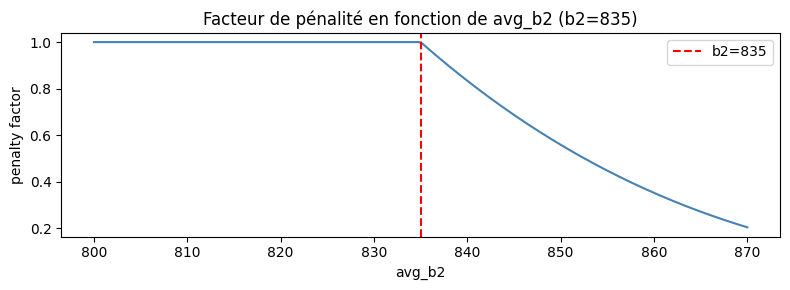

In [2]:
def pnl_single(b1: int, b2: int, avg_b2: float) -> float:
    """
    PnL total pour des bids (b1, b2) étant donné avg_b2.

    Partition des contreparties (par reserve price r):
      r < b1        → trade à b1, marge = 920 - b1 (garanti, indépendant d'avg_b2)
      b1 ≤ r < b2   → trade à b2, marge × factor(avg_b2, b2)
      r ≥ b2        → pas de trade

    factor = 1                              si b2 > avg_b2  (au-dessus de la moyenne)
    factor = ((920-avg_b2)/(920-b2))^3     si b2 ≤ avg_b2  (pénalité)
    Note: factor = 1 quand b2 = avg_b2 (transition continue).
    """
    assert b1 < b2, "b1 doit être strictement inférieur à b2"

    # Segment b1
    n1     = int(np.sum(RESERVE_PRICES < b1))
    pnl_b1 = n1 * (RESELL - b1)

    # Segment b2
    n2       = int(np.sum((RESERVE_PRICES >= b1) & (RESERVE_PRICES < b2)))
    margin2  = RESELL - b2

    if b2 > avg_b2:
        factor = 1.0
    else:
        factor = ((RESELL - avg_b2) / (RESELL - b2)) ** 3 if b2 < RESELL else 0.0

    return float(pnl_b1 + n2 * margin2 * factor)


# ── Sanity checks ──────────────────────────────────────────────────────────────
print("Sanity checks:")
print(f"  b2 > avg_b2 (pas de pénalité) : PnL(750, 835, avg=820) = {pnl_single(750, 835, 820.0):.1f}")
print(f"  b2 = avg_b2 (factor=1)         : PnL(750, 835, avg=835) = {pnl_single(750, 835, 835.0):.1f}")
print(f"  b2 < avg_b2 (pénalisé)         : PnL(750, 835, avg=850) = {pnl_single(750, 835, 850.0):.1f}")
print(f"  b2 < avg_b2 (fort pénalisé)    : PnL(750, 835, avg=900) = {pnl_single(750, 835, 900.0):.1f}")

# Vérifier que le facteur de pénalité est bien continu en avg_b2 = b2
avg_range = np.linspace(800, 870, 200)
factors = np.where(
    avg_range < 835,
    1.0,
    ((920 - avg_range) / (920 - 835)) ** 3
)
plt.figure(figsize=(8, 3))
plt.plot(avg_range, factors, 'steelblue')
plt.axvline(835, color='red', linestyle='--', label='b2=835')
plt.xlabel('avg_b2'); plt.ylabel('penalty factor')
plt.title('Facteur de pénalité en fonction de avg_b2 (b2=835)')
plt.legend(); plt.tight_layout(); plt.show()

## Équilibre de Nash

Au Nash, tous les joueurs rationnels jouent `(b1_nash, b2_nash)`, donc `avg_b2 = b2_nash` → factor = 1.

**Problème d'optimisation** (continu):
$$\max_{b1, b2} \; \frac{b1 - 670}{5}(920 - b1) + \frac{b2 - b1}{5}(920 - b2)$$

**CPO** :
- $\partial/\partial b1$: $(920-b1)-(b1-670) = 920-b2 \Rightarrow b_2 = 2b_1 - 670$
- $\partial/\partial b2$: $920-b_2 = b_2-b_1 \Rightarrow b_2 = (b_1+920)/2$

**Solution**: $b_1^* = 2260/3 \approx 753.3$, $b_2^* = (b_1^*+920)/2 \approx 836.7$

Interprétation: le nombre de contreparties capturées par b1 et b2 est **symétrique** ($n_1 = n_2 \approx 16.7$).

In [3]:
# ── Solution continue ──────────────────────────────────────────────────────────
B1_CONT = 2260 / 3
B2_CONT = (B1_CONT + 920) / 2
N1_CONT = (B1_CONT - 670) / 5
PNL_CONT = N1_CONT * (920 - B1_CONT) + N1_CONT * (920 - B2_CONT)

print(f"Nash continu  : b1 = {B1_CONT:.2f},  b2 = {B2_CONT:.2f}")
print(f"  n1 = n2 = {N1_CONT:.2f}  (captures symétriques)")
print(f"  PnL normalisé = {PNL_CONT:.2f}")

# ── Grille discrète : trouver tous les optimaux ────────────────────────────────
nash_solutions = []
best_pnl_nash  = -np.inf

for b1 in VALID_BIDS:
    for b2 in VALID_BIDS:
        if b2 <= b1:
            continue
        n1 = int(np.sum(RESERVE_PRICES < b1))
        n2 = int(np.sum((RESERVE_PRICES >= b1) & (RESERVE_PRICES < b2)))
        p  = n1 * (RESELL - b1) + n2 * (RESELL - b2)
        if p > best_pnl_nash - 0.5:
            if p > best_pnl_nash:
                best_pnl_nash = p
                nash_solutions = []
            nash_solutions.append((int(b1), int(b2), int(p)))

print(f"\nNash discret (PnL optimal = {best_pnl_nash:.0f}):")
for b1, b2, p in nash_solutions:
    n1 = (b1 - 670) // 5
    n2 = (b2 - b1)  // 5
    print(f"  b1={b1}, b2={b2}  →  n1={n1}×{920-b1} + n2={n2}×{920-b2} = {p}")

B1_NASH, B2_NASH = nash_solutions[0][0], nash_solutions[0][1]
print(f"\nRéférence Nash principale : b1={B1_NASH}, b2={B2_NASH}")

# ── Vérifier : aucune déviation profitable ─────────────────────────────────────
print("\nDéviations unitaires depuis Nash (avg_b2 = b2_nash) :")
print(f"  {'Δb2':>6}   {'b2 dévié':>10}   {'ΔPNL':>10}")
pnl_nash_ref = pnl_single(B1_NASH, B2_NASH, float(B2_NASH))
for delta in [-10, -5, 0, +5, +10, +15]:
    b2_dev = B2_NASH + delta
    if BID_MIN < b2_dev <= BID_MAX and b2_dev > B1_NASH:
        gain = pnl_single(B1_NASH, b2_dev, float(B2_NASH)) - pnl_nash_ref
        print(f"  {delta:>+6}   {b2_dev:>10}   {gain:>+10.1f}")

Nash continu  : b1 = 753.33,  b2 = 836.67
  n1 = n2 = 16.67  (captures symétriques)
  PnL normalisé = 4166.67

Nash discret (PnL optimal = 4165):
  b1=750, b2=835  →  n1=16×170 + n2=17×85 = 4165
  b1=755, b2=835  →  n1=17×165 + n2=16×85 = 4165
  b1=755, b2=840  →  n1=17×165 + n2=17×80 = 4165

Référence Nash principale : b1=750, b2=835

Déviations unitaires depuis Nash (avg_b2 = b2_nash) :
     Δb2     b2 dévié         ΔPNL
     -10          825       -424.3
      -5          830       -231.9
      +0          835         +0.0
      +5          840         -5.0
     +10          845        -20.0
     +15          850        -45.0


## Types de joueurs (non-Nash)

| Type | Nom | Comportement | b2 attendu | Motivation |
|------|-----|--------------|------------|------------|
| A | Nash joint | Résout (b1,b2) jointement avec avg_b2=b2 | ~837 | Rationnel coordonné |
| B | Optimiseur séquentiel | Optimise b1 indépendamment (→795), puis b2 donné b1=795 | ~857 | Biais de décomposition |
| C | Greedy haut | Maximise le volume capturé, ignore la marge | ~895-915 | Biais de maximisation du volume |
| D | Ancrage milieu | Heuristique intuitive autour de 820 | ~820 | Ancrage cognitif |

**Rationnel scientifique**: les Types B/C/D ne sont pas "random" mais reflètent des biais documentés en économie comportementale (bounded rationality, salience heuristics, partition dependence).

In [4]:
def sample_b2_type(player_type: str, n: int) -> np.ndarray:
    """
    Échantillonne n valeurs de b2 pour un type de joueur.

    Type A – Nash : cluster serré autour de b2_nash=837
    Type B – Séquentiel : optimise b1=795 en premier, puis b2 donné b1 → 857
               (erreur de décomposition : ignore que b2-b1 cannibalisent)
    Type C – Greedy haut : cible le volume maximal de contreparties, b2 élevé
               (ignore l'effondrement de marge à b2 proche de 920)
    Type D – Ancrage milieu : heuristique autour de 820 ("entre les deux")
    """
    if player_type == 'A':
        raw = np.random.normal(B2_NASH, 4.0, n)
    elif player_type == 'B':
        # Type B: b1=795 indépendamment, puis b2 = argmax (b2-795)*(920-b2)
        # → b2_opt_given_b1=795 = (920+795)/2 = 857.5
        raw = np.random.normal(857.5, 6.0, n)
    elif player_type == 'C':
        # Greedy: vise 880-915 uniformément
        choices = np.arange(880, 916, BID_STEP)
        return np.random.choice(choices, size=n)
    elif player_type == 'D':
        # Ancrage autour de 820
        raw = np.random.normal(820, 25.0, n)
    else:
        raise ValueError(f"Type inconnu: {player_type}")

    snapped = np.round(raw / BID_STEP) * BID_STEP
    return np.clip(snapped, BID_MIN, BID_MAX).astype(int)


def sample_b2_mixed(proportions: dict, n: int) -> np.ndarray:
    """Génère n valeurs de b2 depuis un champ de composition 'proportions'."""
    parts = []
    remaining = n
    types = list(proportions.keys())
    for i, t in enumerate(types):
        size = int(proportions[t] * n) if i < len(types) - 1 else remaining
        parts.append(sample_b2_type(t, size))
        remaining -= size
    return np.concatenate(parts)


# Afficher les distributions par type
print(f"{'Type':<8} {'E[b2]':>8} {'std':>6} {'min':>6} {'max':>6}")
print("-" * 36)
for t in ['A', 'B', 'C', 'D']:
    s = sample_b2_type(t, 50_000)
    print(f"  {t:<6} {s.mean():>8.1f} {s.std():>6.1f} {s.min():>6} {s.max():>6}")

# Note: pourquoi b2_opt_given_b1=795 = 857.5 ?
# Maximiser (b2-795)/5 * (920-b2) → FOC: (920-b2) = (b2-795) → b2 = 857.5
print(f"\nVérification Type B: b2_opt donné b1=795 = {(920+795)/2:.1f}")

Type        E[b2]    std    min    max
------------------------------------
  A         835.0    4.2    820    850
  B         857.5    6.2    830    880
  C         897.5   11.5    880    915
  D         820.1   25.0    720    920

Vérification Type B: b2_opt donné b1=795 = 857.5


## Distribution de avg_b2

**Pourquoi avg_b2 est quasi-déterministe** : avec N ≈ 20 000 équipes, par le TCL :
$$\text{std}(\overline{b_2}) = \frac{\text{std}(b_2^{\text{individuel}})}{\sqrt{N}} \approx \frac{\sigma_{b2}}{141}$$

Donc même si `std(b2_indiv) ≈ 30`, on a `std(avg_b2) ≈ 0.2` → très concentré.

L'**incertitude résiduelle** vient de notre incertitude sur la *composition* du champ → modélisée par un **prior Dirichlet** sur les proportions.

In [5]:
N_TEAMS = 5000  # hypothèse sur la taille du champ


def sample_avg_b2_distribution(
    proportions: dict,
    n_teams:  int   = N_TEAMS,
    n_draws:  int   = 5_000,
    dirichlet_concentration: float = 80.0,
) -> np.ndarray:
    """
    Échantillonne n_draws réalisations de avg_b2.

    Deux sources d'incertitude:
      - Outer (Dirichlet): incertitude sur la composition réelle du champ
        concentration élevée → fort belief en 'proportions'
        concentration ≈ 1   → complètement incertain sur les proportions
      - Inner (CLT): variance résiduelle du b2 moyen donné une composition
        (≈ 0 avec N=20k → on utilise la loi des grands nombres directement)

    Note: les types avec proportion=0 sont ignorés (Dirichlet exige alpha > 0).
    """
    # Filtrer les types avec proportion 0 (Dirichlet exige alpha > 0)
    active      = {t: p for t, p in proportions.items() if p > 0}
    types       = list(active.keys())
    base_props  = np.array([active[t] for t in types])
    base_props  = base_props / base_props.sum()   # renormaliser au cas où
    alpha       = base_props * dirichlet_concentration

    # Moyennes analytiques par type (E[b2] par type)
    type_means = {t: sample_b2_type(t, 100_000).mean() for t in types}

    avg_b2_samples = []
    for _ in range(n_draws):
        # Tirer une composition depuis le prior Dirichlet
        props = np.random.dirichlet(alpha)

        # avg_b2 ≈ somme pondérée des moyennes par type (approximation CLT)
        # + bruit résiduel négligeable (σ/√N ≈ 0.2)
        avg_b2 = sum(props[i] * type_means[t] for i, t in enumerate(types))
        avg_b2_samples.append(avg_b2)

    return np.array(avg_b2_samples)


# Vérifier l'approximation CLT
print("Vérification CLT — std(avg_b2) ≈ std(b2_indiv) / √N :")
for t in ['A', 'B', 'C', 'D']:
    b2_s = sample_b2_type(t, 200_000)
    std_pred = b2_s.std() / np.sqrt(N_TEAMS)
    print(f"  Type {t}: E[b2]={b2_s.mean():.1f}, std_indiv={b2_s.std():.1f}, "
          f"std(avg_b2) prédit = {std_pred:.3f}")

print(f"\n→ Avec N={N_TEAMS}, avg_b2 est quasi-déterministe donné une composition.")
print(  "  L'incertitude principale est SUR la composition (prior Dirichlet).")


Vérification CLT — std(avg_b2) ≈ std(b2_indiv) / √N :
  Type A: E[b2]=835.0, std_indiv=4.3, std(avg_b2) prédit = 0.060
  Type B: E[b2]=857.5, std_indiv=6.1, std(avg_b2) prédit = 0.087
  Type C: E[b2]=897.5, std_indiv=11.5, std(avg_b2) prédit = 0.162
  Type D: E[b2]=820.0, std_indiv=25.0, std(avg_b2) prédit = 0.354

→ Avec N=5000, avg_b2 est quasi-déterministe donné une composition.
  L'incertitude principale est SUR la composition (prior Dirichlet).


In [6]:
# ── Scénarios ──────────────────────────────────────────────────────────────────
SCENARIOS = {
    "S1: 85% Nash, 5%B, 7%C, 1%D":    {'A': 0.85, 'B': 0.05, 'C': 0.07, 'D': 0.01},
    "S2: 80% Nash, 20% mixte":         {'A': 0.80, 'B': 0.08, 'C': 0.07, 'D': 0.05},
    "S3: 95% Nash,  5% mixte":         {'A': 0.95, 'B': 0.02, 'C': 0.02, 'D': 0.01},
    "S4: 90% Nash, 10% greedy (C)":    {'A': 0.90, 'B': 0.00, 'C': 0.10, 'D': 0.00},
    "S5: 70% Nash, 30% greedy (C)":    {'A': 0.70, 'B': 0.00, 'C': 0.30, 'D': 0.00},
}

print(f"{'Scénario':<42} {'E[avg_b2]':>10} {'std':>6} {'P(avg>b2_nash)':>16}")
print("-" * 78)

avg_b2_by_scenario = {}
for name, props in SCENARIOS.items():
    samp = sample_avg_b2_distribution(props)
    avg_b2_by_scenario[name] = samp
    print(f"{name:<42} {samp.mean():>10.2f} {samp.std():>6.3f} "
          f"{np.mean(samp > B2_NASH):>15.1%}")

Scénario                                    E[avg_b2]    std   P(avg>b2_nash)
------------------------------------------------------------------------------
S1: 85% Nash, 5%B, 7%C, 1%D                    840.47  1.865          100.0%
S2: 80% Nash, 20% mixte                        840.40  1.944          100.0%
S3: 95% Nash,  5% mixte                        836.54  1.037           98.8%
S4: 90% Nash, 10% greedy (C)                   841.25  2.079          100.0%
S5: 70% Nash, 30% greedy (C)                   853.73  3.265          100.0%


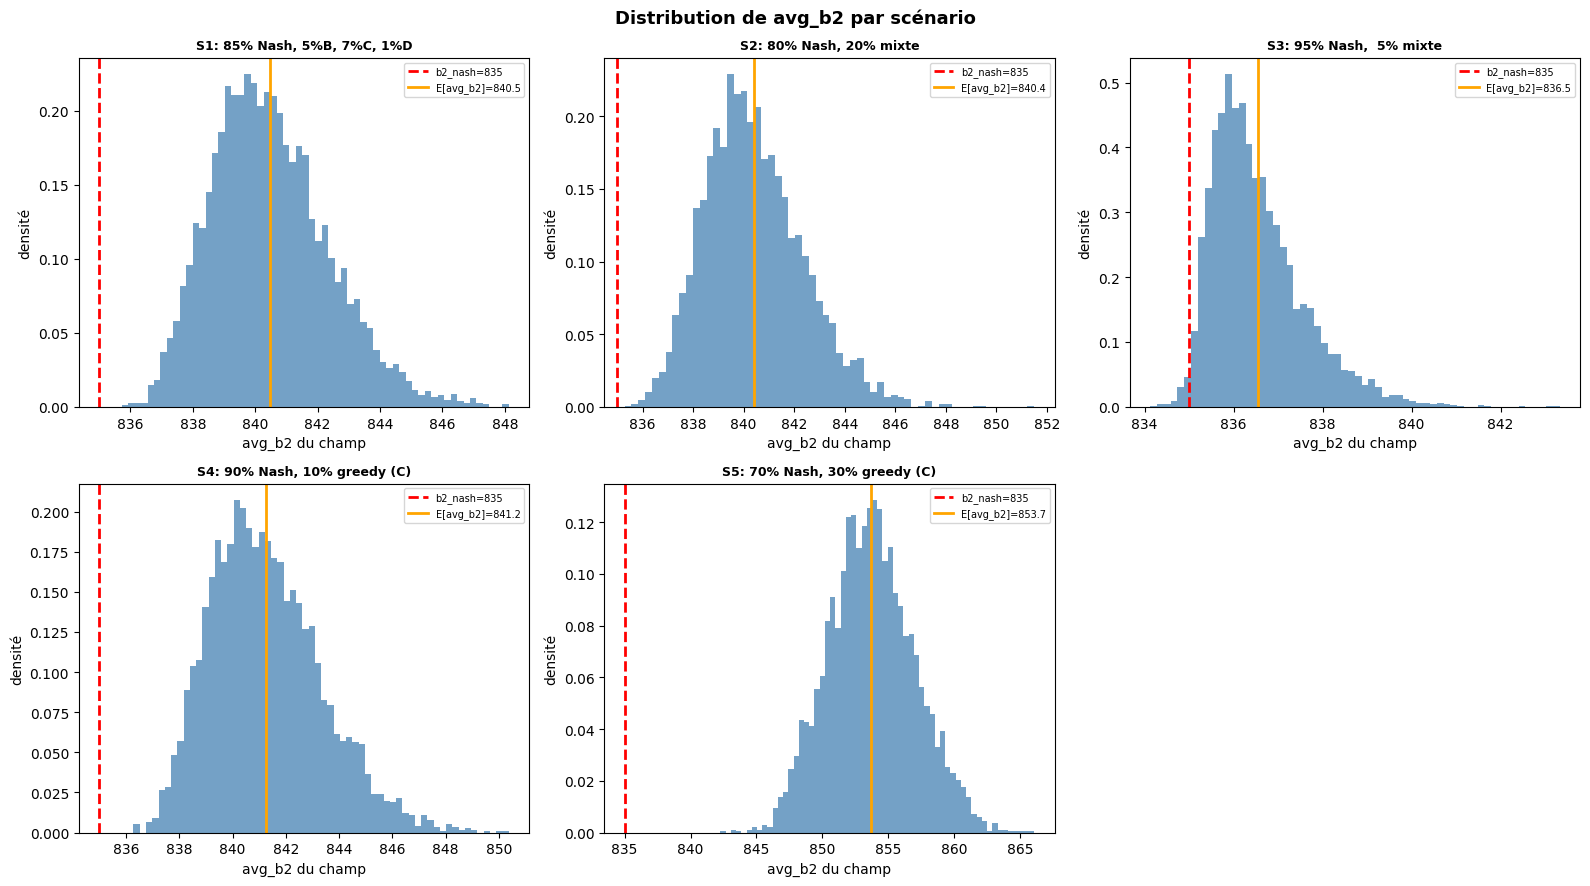

In [7]:
# ── Visualisation des distributions de avg_b2 ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, samp) in zip(axes, avg_b2_by_scenario.items()):
    ax.hist(samp, bins=60, color='steelblue', alpha=0.75, density=True)
    ax.axvline(B2_NASH, color='red',    lw=2, linestyle='--', label=f'b2_nash={B2_NASH}')
    ax.axvline(samp.mean(), color='orange', lw=2, label=f"E[avg_b2]={samp.mean():.1f}")
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('avg_b2 du champ')
    ax.set_ylabel('densité')

axes[-1].set_visible(False)
plt.suptitle("Distribution de avg_b2 par scénario", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Grille E[PnL(b1, b2)]

In [8]:
def compute_expected_pnl_grid(avg_b2_samples: np.ndarray) -> pd.DataFrame:
    """
    Calcule E[PnL(b1, b2)] pour toutes les paires (b1<b2) de la grille.

    Vectorisé sur avg_b2_samples : pour chaque (b1,b2), on calcule
    pnl_single(b1, b2, avg_b2) pour chaque tirage puis on prend la moyenne.
    """
    results = []
    for b1 in VALID_BIDS:
        for b2 in VALID_BIDS:
            if b2 <= b1:
                continue

            n1      = int(np.sum(RESERVE_PRICES < b1))
            n2      = int(np.sum((RESERVE_PRICES >= b1) & (RESERVE_PRICES < b2)))
            margin2 = int(RESELL - b2)
            pnl_b1  = n1 * (RESELL - b1)

            # Facteur de pénalité vectorisé
            is_above = avg_b2_samples < b2            # True → pas de pénalité
            if b2 < RESELL:
                factors = np.where(
                    is_above,
                    1.0,
                    ((RESELL - avg_b2_samples) / margin2) ** 3,
                )
            else:
                factors = np.zeros(len(avg_b2_samples))

            epnl = pnl_b1 + n2 * margin2 * factors.mean()

            results.append({
                'b1':             int(b1),
                'b2':             int(b2),
                'n1':             n1,
                'n2':             n2,
                'margin1':        int(RESELL - b1),
                'margin2':        margin2,
                'expected_pnl':   epnl,
                'p_above_avg':    is_above.mean(),   # P(b2 > avg_b2) = P(pas de pénalité)
            })

    return pd.DataFrame(results)


# Lancer sur le scénario principal
PRIMARY = "S1: 90% Nash, 10% mixte"
print(f"Calcul de la grille pour : {PRIMARY}")
df_primary = compute_expected_pnl_grid(avg_b2_by_scenario[PRIMARY])

best = df_primary.loc[df_primary['expected_pnl'].idxmax()]
nash_row = df_primary[(df_primary.b1 == B1_NASH) & (df_primary.b2 == B2_NASH)]
nash_epnl = nash_row.expected_pnl.values[0]

print(f"\nOptimal : b1={int(best.b1)}, b2={int(best.b2)}, E[PnL]={best.expected_pnl:.2f}")
print(f"  n1={int(best.n1)} × margin {int(best.margin1)} + n2={int(best.n2)} × margin {int(best.margin2)}")
print(f"  P(b2 > avg_b2) = {best.p_above_avg:.1%}")
print(f"\nNash pur : b1={B1_NASH}, b2={B2_NASH}, E[PnL]={nash_epnl:.2f}")
print(f"Gain vs Nash : {best.expected_pnl - nash_epnl:+.2f}")

Calcul de la grille pour : S1: 90% Nash, 10% mixte


KeyError: 'S1: 90% Nash, 10% mixte'

In [ ]:
# ── Heatmap interactive (Plotly) ───────────────────────────────────────────────
def plot_heatmap(df: pd.DataFrame, scenario_name: str):
    pivot = df.pivot(index='b1', columns='b2', values='expected_pnl')
    best  = df.loc[df['expected_pnl'].idxmax()]

    fig = go.Figure()
    fig.add_trace(go.Heatmap(
        z=pivot.values,
        x=pivot.columns.astype(int),
        y=pivot.index.astype(int),
        colorscale='Viridis',
        colorbar=dict(title='E[PnL]'),
        hovertemplate="b1=%{y}, b2=%{x}<br>E[PnL]=%{z:.1f}<extra></extra>",
    ))
    fig.add_trace(go.Scatter(
        x=[best.b2], y=[best.b1], mode='markers+text',
        marker=dict(color='red', size=14, symbol='star'),
        text=[f" OPT ({int(best.b1)},{int(best.b2)})"],
        textposition='middle right', name='Optimal',
        textfont=dict(color='red', size=11),
    ))
    fig.add_trace(go.Scatter(
        x=[B2_NASH], y=[B1_NASH], mode='markers+text',
        marker=dict(color='white', size=11, symbol='x'),
        text=[f" Nash ({B1_NASH},{B2_NASH})"],
        textposition='middle right', name='Nash pur',
        textfont=dict(color='white', size=10),
    ))
    fig.update_layout(
        title=f"E[PnL(b1, b2)] — {scenario_name}",
        xaxis_title="b2 (enchère haute)",
        yaxis_title="b1 (enchère basse)",
        height=600, width=950,
    )
    fig.show()
    return best

best_primary = plot_heatmap(df_primary, PRIMARY)

## Optimisation pour tous les scénarios

In [ ]:
opt_results = []

for name, avg_b2_samp in avg_b2_by_scenario.items():
    print(f"\n{'='*65}")
    print(f"Scénario : {name}")
    print(f"  E[avg_b2] = {avg_b2_samp.mean():.2f}   std = {avg_b2_samp.std():.3f}")

    df = compute_expected_pnl_grid(avg_b2_samp)
    best = df.loc[df['expected_pnl'].idxmax()]
    nash_epnl = df[(df.b1 == B1_NASH) & (df.b2 == B2_NASH)].expected_pnl.values[0]

    opt_results.append({
        'scenario':     name,
        'E_avg_b2':     round(avg_b2_samp.mean(), 2),
        'opt_b1':       int(best.b1),
        'opt_b2':       int(best.b2),
        'opt_epnl':     round(best.expected_pnl, 2),
        'nash_epnl':    round(nash_epnl, 2),
        'gain_vs_nash': round(best.expected_pnl - nash_epnl, 2),
        'p_above_avg':  round(best.p_above_avg, 3),
    })

    print(f"  Optimal : b1={int(best.b1)}, b2={int(best.b2)}, E[PnL]={best.expected_pnl:.2f}")
    print(f"  Nash    : b1={B1_NASH},  b2={B2_NASH},  E[PnL]={nash_epnl:.2f}")
    print(f"  Gain vs Nash : {best.expected_pnl - nash_epnl:+.2f}")

opt_df = pd.DataFrame(opt_results)
print("\n\n=== TABLEAU RÉCAPITULATIF ===")
print(opt_df.to_string(index=False))


Scénario : S1: 90% Nash, 10% mixte
  E[avg_b2] = 837.36   std = 1.318
  Optimal : b1=755, b2=840, E[PnL]=4163.21
  Nash    : b1=750,  b2=835,  E[PnL]=4048.72
  Gain vs Nash : +114.49

Scénario : S2: 80% Nash, 20% mixte
  E[avg_b2] = 840.37   std = 1.899
  Optimal : b1=760, b2=845, E[PnL]=4154.00
  Nash    : b1=750,  b2=835,  E[PnL]=3910.03
  Gain vs Nash : +243.97

Scénario : S3: 95% Nash,  5% mixte
  E[avg_b2] = 836.53   std = 1.031
  Optimal : b1=755, b2=840, E[PnL]=4164.75
  Nash    : b1=750,  b2=835,  E[PnL]=4089.06
  Gain vs Nash : +75.69

Scénario : S4: 90% Nash, 10% greedy (C)
  E[avg_b2] = 841.24   std = 2.104
  Optimal : b1=760, b2=845, E[PnL]=4151.81
  Nash    : b1=750,  b2=835,  E[PnL]=3871.81
  Gain vs Nash : +280.00

Scénario : S5: 70% Nash, 30% greedy (C)
  E[avg_b2] = 853.78   std = 3.176
  Optimal : b1=765, b2=860, E[PnL]=4082.62
  Nash    : b1=750,  b2=835,  E[PnL]=3407.96
  Gain vs Nash : +674.65


=== TABLEAU RÉCAPITULATIF ===
                    scenario  E_avg_b2 

## Analyse de sensibilité : fraction Nash de 50% à 99%

 nash_fraction  E_avg_b2  opt_b1  opt_b2  opt_epnl  p_above_avg
          0.50    848.57     765     855   4114.23        0.986
          0.55    847.20     760     850   4128.02        0.856
          0.60    845.86     760     850   4136.31        0.937
          0.65    844.50     760     850   4139.15        0.983
          0.70    843.12     760     850   4139.76        0.996
          0.75    841.82     760     845   4150.34        0.923
          0.80    840.44     760     845   4153.80        0.980
          0.85    839.10     760     845   4154.96        0.999
          0.90    837.71     755     840   4161.73        0.929
          0.95    836.34     755     840   4164.84        0.996
          1.00    835.01     755     840   4165.00        1.000


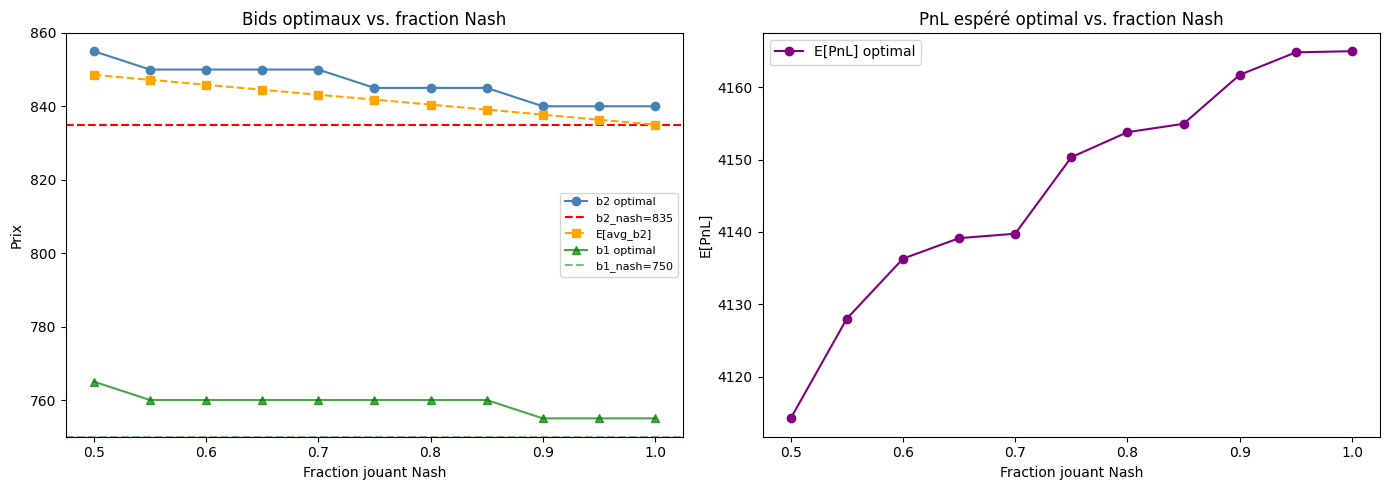

In [ ]:
nash_fractions = np.arange(0.50, 1.01, 0.05)
sens_records   = []

for frac in nash_fractions:
    rem = 1.0 - frac
    # Les non-Nash sont splittés : 40% B, 35% C (greedy), 25% D
    props = {'A': frac, 'B': rem * 0.40, 'C': rem * 0.35, 'D': rem * 0.25}
    samp  = sample_avg_b2_distribution(props, n_draws=3_000)
    df    = compute_expected_pnl_grid(samp)
    best  = df.loc[df['expected_pnl'].idxmax()]

    sens_records.append({
        'nash_fraction': round(frac, 2),
        'E_avg_b2':      round(samp.mean(), 2),
        'opt_b1':        int(best.b1),
        'opt_b2':        int(best.b2),
        'opt_epnl':      round(best.expected_pnl, 2),
        'p_above_avg':   round(best.p_above_avg, 3),
    })

sens_df = pd.DataFrame(sens_records)
print(sens_df.to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sens_df.nash_fraction, sens_df.opt_b2, 'o-', color='steelblue', label='b2 optimal')
ax1.axhline(B2_NASH, color='red',    linestyle='--', label=f'b2_nash={B2_NASH}')
ax1.plot(sens_df.nash_fraction, sens_df.E_avg_b2, 's--', color='orange', label='E[avg_b2]')
ax1.plot(sens_df.nash_fraction, sens_df.opt_b1, '^-', color='green', alpha=0.7, label='b1 optimal')
ax1.axhline(B1_NASH, color='green',  linestyle='--', alpha=0.5, label=f'b1_nash={B1_NASH}')
ax1.set_xlabel('Fraction jouant Nash'); ax1.set_ylabel('Prix')
ax1.set_title('Bids optimaux vs. fraction Nash'); ax1.legend(fontsize=8)

ax2.plot(sens_df.nash_fraction, sens_df.opt_epnl, 'o-', color='purple', label='E[PnL] optimal')
ax2.set_xlabel('Fraction jouant Nash'); ax2.set_ylabel('E[PnL]')
ax2.set_title('PnL espéré optimal vs. fraction Nash')
ax2.legend()

plt.tight_layout(); plt.show()

## Recommandation finale